In [1]:
#https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing?resource=download

# Анализ результатов А/Б-тестирования в мобильной игре "Cookie Cats"

### Context / Контекст бизнеса
"Cookie Cats" — это популярная мобильная игра-головоломка в стиле "три в ряд". В процессе прохождения игроки периодически сталкиваются с "воротами" (gates), которые заставляют их сделать паузу: либо подождать определенное время, либо совершить внутриигровую покупку, чтобы продолжить игру. Эти ворота служат важным инструментом монетизации и контроля темпа игры (категория гейм-дизайна), однако они могут негативно влиять на вовлеченность пользователей (Retention).

### Experiment / Суть эксперимента
Команда разработчиков решила протестировать гипотезу: **что произойдет, если перенести первые ворота с 30-го уровня на 40-й уровень?** 
Цель изменений — дать пользователям подольше поиграть без ограничений, чтобы повысить их удержание и общую активность. Для проверки была запущена А/Б-тест кампания, где пользователи были разделены на две группы:
* **Контрольная группа:** первые ворота находятся на 30-м уровне (`gate_30`).
* **Тестовая группа:** первые ворота перенесены на 40-й уровень (`gate_40`).

---

### Data Structure / Описание данных
Каждая строка датасета представляет собой уникального игрока, который установил игру во время проведения эксперимента. В таблице представлены следующие признаки:

* `userid` — уникальный идентификационный номер игрока.
* `version` — группа, в которую попал пользователь (`gate_30` или `gate_40`).
* `sum_gamerounds` — общее количество игровых раундов, сыгранных пользователем в течение первых 14 дней после установки.
* `retention_1` — вернулся ли игрок в игру через 1 день после установки? (`True` / `False`).
* `retention_7` — вернулся ли игрок в игру через 7 дней после установки? (`True` / `False`).

---

### Задачи исследования

Главная цель этого проекта — определить, как перенос игрового барьера (ворот) влияет на поведение пользователей и метрики удержания. Задачи проекта:

1. **Контроль качества данных:** Оценим корректность разделения трафика на группы А и Б, обнаружить и удалить выбросы и дубликаты, если они есть.
2. **Анализ вовлеченности:** Исследуем распределение сыгранных раундов внутри каждой группы. Найдем скрытые закономерности в поведении пользователей на разных этапах прохождения игры.
3. **Расчет продуктовых метрик:** Рассчитаем показатели удержания клиентов 1-го и 7-го дня (Retention Rate), чтобы увидеть первичный вектор изменений.
4. **Проверка статистической значимости:** Применим математические критерии к метрикам удержания. Это поможет доказать, является ли изменение показателей реальным следствием эксперимента или обычным случайным шумом.
5. **Бизнес-выводы и рекомендации:** Сформулируем аргументированное решение для команды гейм-дизайна — стоит ли внедрять обновление на всех игроков, предложу шаги для дальнейшего развития продукта.



## Загрузка и обработка данных

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

In [3]:
df = pd.read_csv('cookie_cats.csv')

# Создаем движок (engine) SQLAlchemy для базы данных SQLite в памяти
engine = create_engine('sqlite:///:memory:')

#Сохраняем датасет в таблицу 'game_logs' через SQLAlchemy
df.to_sql('game_logs', con=engine, index=False, if_exists='replace')


90189

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [5]:
# проверим работу базы данных
query = '''
SELECT *
FROM game_logs
LIMIT 5;
'''
pd.read_sql_query(query,con=engine)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,0,0
1,337,gate_30,38,1,0
2,377,gate_40,165,1,0
3,483,gate_40,1,0,0
4,488,gate_40,179,1,1


проверим размеры выборок (тестовой и контрольной)

In [6]:
query = '''
SELECT COUNT(userid),
       version
FROM game_logs
GROUP BY version
'''
pd.read_sql_query(query,con=engine)

,COUNT(userid),version
0,44700,gate_30
1,45489,gate_40


In [7]:
print(f'Группа gate_30 (Контроль): 44 700 игроков (около {44700/(44700+45489):.1%})')
print(f'Группа gate_30 (Контроль): 45489 игроков (около {45489/(44700+45489):.1%})')
print(f'Всего в датасете {44700+45489} участников')

Группа gate_30 (Контроль): 44 700 игроков (около 49.6%)
Группа gate_30 (Контроль): 45489 игроков (около 50.4%)
Всего в датасете 90189 участников


--------------------------------------------------------
Выборки разделились практически идеально в пропорции 50/50. Небольшой перекос в 0.8% допустим для А/Б-тестов. Система сплитования (разделения трафика) отработала корректно, группы однородны по объему, мы можем продолжать анализ

## Первичный анализ данных

### Поиск аномалий в данных

In [8]:
# Проверка на явные дубликаты
df.duplicated().sum()

np.int64(0)

In [9]:
# Мне не нравится название столбца "userid", переведу его в змеиный регистр
df.rename(columns={'userid':'user_id'}, inplace=True)

In [10]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Мы видим, что среднее значение 51.9 и медиана 16 очень далеки друг от друга. Помимо этого максимальное значние 49854 кажется огромным и нереалистичным. 49 854 раунда за 14 дней означает, что пользователь должен был играть примерно по 3 500 раундов в день без перерыва на сон и еду. Это физически невозможно для человека - скорее всего, это технический баг логирования или игровой бот.

В данных явно присутствуют большие выбросы, которые сдвигают среднее значение и портят данные. Проферим это, построив график boxplot

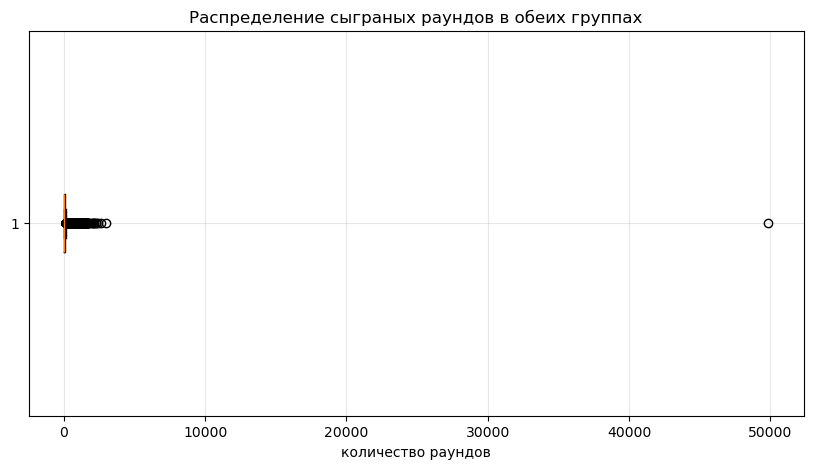

In [11]:
plt.figure(figsize=(10,5))
plt.boxplot(df['sum_gamerounds'],vert=False)
plt.title('Распределение сыграных раундов в обеих группах')
plt.xlabel('количество раундов')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
df[df['sum_gamerounds']>10000]['user_id'].count()

np.int64(1)

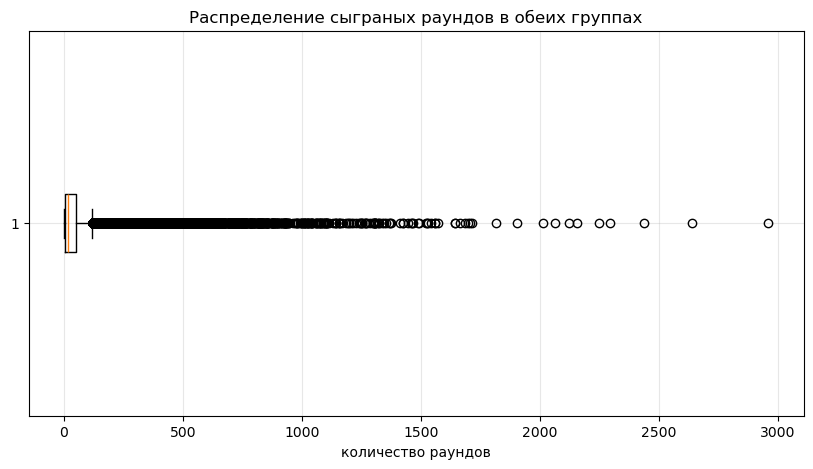

In [14]:
df= df[df['sum_gamerounds']<10000]
plt.figure(figsize=(10,5))
plt.boxplot(df['sum_gamerounds'],vert=False)
plt.title('Распределение сыграных раундов в обеих группах')
plt.xlabel('количество раундов')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
df['sum_gamerounds'].describe()

count    90188.000000
mean        51.320253
std        102.682719
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64

Теперь максимальное значение равно 2961, что тоже кажется большим, но уже реалистичным числом, если игрок проводит за игрой много времени

---------------------------------------------------------------
Даже после удаления супер-выброса среднее значение существенно превышает медиану. Это указывает на то, что распределение активности игроков имеет сильную правостороннюю асимметрию. В данных присутствует небольшая доля очень вовлеченных игроков, которые генерируют основной объем сыгранных раундов. Для сравнения таких распределений стандартный t-test может быть неэффективен, поэтому далее мы детально изучим форму распределения и подберем правильные стат-критерии

-------------------------------------------------------------------

Рассмотрим распределение данных по тестовой и контрольной группе, узнаем, есть ли между ними отличия

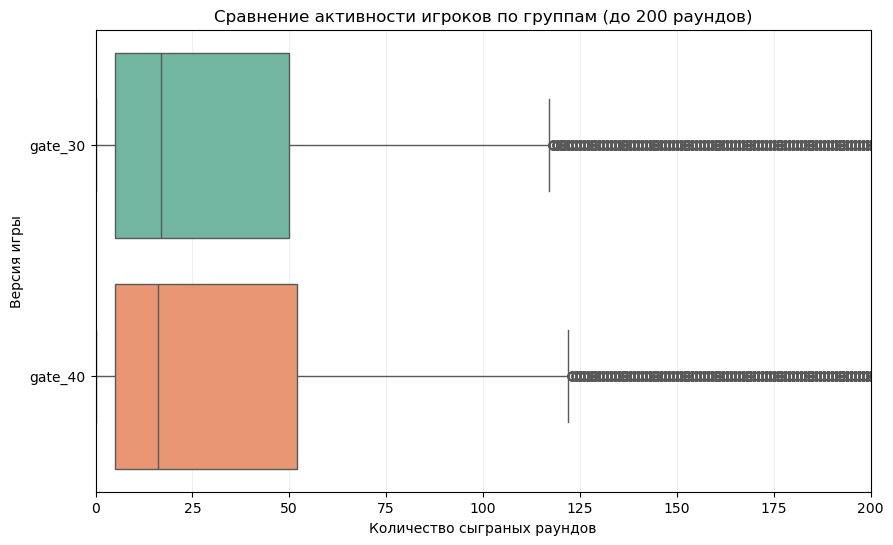

In [16]:
plt.figure(figsize=(10,6))
# Строим раздельные ящики для каждой группы, ограничив график до 200 раундов, чтобы "хвост" не мешал рассмотреть детали
sns.boxplot(data=df, x='sum_gamerounds', y='version', hue='version', palette='Set2', legend=False)
plt.xlim(0,200)

plt.title('Сравнение активности игроков по группам (до 200 раундов)')
plt.xlabel('Количество сыграных раундов')
plt.ylabel('Версия игры')
plt.grid(True,alpha=0.2)
plt.show()

Большой разницы между распределениями не замечено. Медиана кажется на одном и том же месте, а вот правый ус у тестовой группы немного сдвинут вправо, также как и 75 перцентиль. Это может говорить о том, что больше пользователей прошли до примерно 50 уровня. Но вот значима ли эта разница статистически - это еще предстоит выяснить

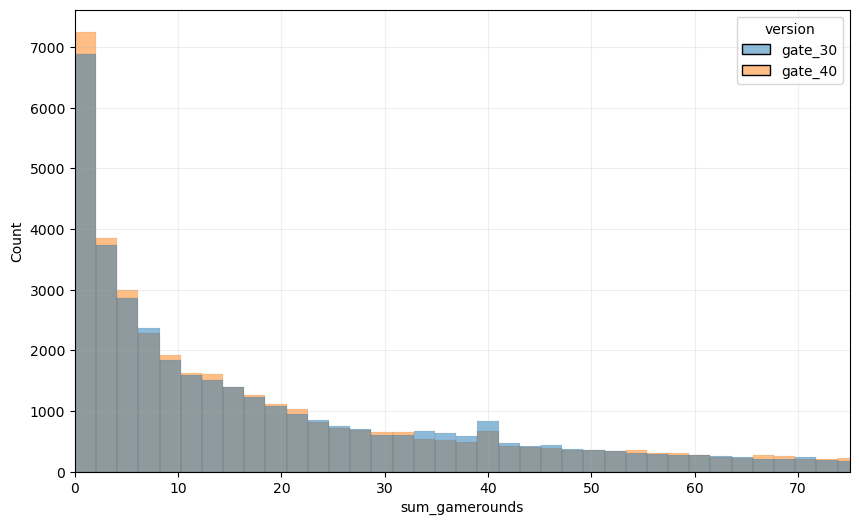

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='sum_gamerounds', hue='version',multiple='layer',alpha=0.5)
plt.xlim(0,75)
plt.grid(True,alpha=0.2)
plt.show()

### Расчет ключевых продуктовых метрик (Retention)

In [18]:
retention_metrics = df.groupby('version')[['retention_1','retention_7']].mean()
print(round(retention_metrics*100,1))

         retention_1  retention_7
version                          
gate_30         44.8         19.0
gate_40         44.2         18.2


Разработчики ожидали, что перенос ворот дальше по уровню даст пользователям больше свободы и увеличит удержание. Но цифры говорят о другом:

Retention 1-го дня упал с 44.8% до 44.2% (минус 0.6%).

Retention 7-го дня упал с 19.0% до 18.2% (минус 0.8%).

### Выводы по итогам EDA

Проведя первичный анализ данных я прихожу к выводу, что после 30-го уровня пользователи из контрольной группы играли больше чем пользователи из тестовой. Получается, перерыв, который у них был из-за первых ворот, как бы подстегнул их играть больше, а не оттолкнул. А вот в тестовой группе много кто дошел до 40 уровня, а после появления первых ворот бросил игру, видимо, решив, что поиграл достаточно, поэтому мотивации смотреть рекламу или платить и играть дальше, уже было сильно меньше.

Помимо этого, судя по гистограмме, у нас также много пользователей в контрольной группе дошли до 40-го уровня и сразу бросили игру. Это может говорить о том, что этот уровень сам по себе сложный. Пользователи "застревают" на нем и не могут продолжать игру. 

Также этот спад может быть связан с общей усталостью от игры и спадом интереса.

На 40-м уровне на игрока (из обеих групп) накладывается сразу три фактора стресса:
* Он уже наигрался и физически устал за 40 раундов подряд.
* Он уперся в объективно сложный уровень.
* Игра впервые жестко заблокировала его «воротами» монетизации

В контрольной группе эти стрессы были распределены во времени: сначала они пережили ворота на 30-м уровне, отдохнули, вернулись в азарт, и к 40-му уровню подошли более вовлеченными. А на тестовую группу всё свалилось одновременно, что и привело к резкому оттоку.

## Статистическая проверка гипотезы

H0: retention_control = retention_test

H1: retention_control ≠ retention_test

Для проверки гипотезы мы будем использовать z-тест, так как он больше всего подходит для бинарных величин

In [19]:
df_r1 = df.groupby('version')['retention_1'].agg(['sum','count'])
df_r1

,sum,count
version,,
gate_30,20034,44699
gate_40,20119,45489


In [20]:
# Задаем количество успехов и общее число игроков для Retention 1
successes_r1 = np.array([20034, 20119])
nobs_r1 = np.array([44699, 45489])

alpha = .05
z_stat_r1, p_value_r1 = proportions_ztest(successes_r1, nobs_r1, alternative='two-sided')

print(f"p-value для Retention 1: {p_value_r1:.4f}")
if p_value_r1 < alpha:
    print('Отвергаем 0 гипотезу, обнаружена статистическая значимость')
else:
    print('Не можем отвергнуть 0 гипотезу')

p-value для Retention 1: 0.0739
Не можем отвергнуть 0 гипотезу


По результатам z-теста мы не можем отвергнуть 0 гипотезу, следовательно статистической значимости удержания после 1 дня между двумя группами не обнаружено.

Проверим данные за 7 день.

In [21]:
df_r7 = df.groupby('version')['retention_7'].agg(['sum','count'])
df_r7

,sum,count
version,,
gate_30,8501,44699
gate_40,8279,45489


In [22]:
successes_r7 = np.array([8501,8279])
nobs_r7 = np.array([44699,45489])
z_stat_r7, p_value_r7 = proportions_ztest(successes_r7, nobs_r7, alternative='two-sided')

print(f"p-value для Retention 7: {p_value_r7:.4f}")
if p_value_r7 < alpha:
    print('Отвергаем 0 гипотезу, обнаружена статистическая значимость')
else:
    print('Не можем отвергнуть 0 гипотезу')

p-value для Retention 7: 0.0016
Отвергаем 0 гипотезу, обнаружена статистическая значимость


По результатам второго теста 0 гипотезу удалось отвергнуть. Можем утверждать с большой вероятностью, что удержание в тестовой группе не равно удержанию во второй. Судя по средним значениям, которые мы вычисляли ранее, retention у тестовой группы на 7 день упал, а не увеличился, как изначально предполагалось.

## Общий итог

* Retention 1-day (Краткосрочное удержание): Падение метрики с 44.8% до 44.2% оказалось статистически незначимым (p-value = 0.074). В первые сутки большинство игроков просто не успевают дойти до 30-го уровня, поэтому изменение механики ворот на них не повлияло.

* Retention 7-day (Долгосрочное удержание): Падение метрики с 19.0% до 18.2% является статистически значимым (p-value = 0.0016). Перенос первых ворот на 40-й уровень нанёс сильный урон удержанию игроков в течение первой недели.

* Причина: Как показала гистограмма активности, отсутствие ранних ограничений приводит к тому, что игроки успевают пресытиться геймплеем и почувствовать усталость к 40-му уровню. Когда игра впервые блокирует их воротами, у них больше нет мотивации оставаться. Ранние ворота на 30-м уровне, напротив, создавали интригу и «эффект незавершенного действия», заставляя людей возвращаться.

## Итоговое решение и рекомендации

* Не рекомендуется раскатывать обновление с переносом ворот на 40-й уровень на всех пользователей. Лучше оставить текущую механику появления первых ворот на 30 уровне, так как она приносит игре больше лояльных пользователей.

* Возможно имеет смысл сместить ворота на 10 уровней назад и оценить полученный результат.
На 20-м уровне игрок еще находится в фазе «новичка», у него высокий интерес, игра кажется легкой и динамичной. Принудительная пауза на этом этапе может вызвать еще более сильное желание вернуться, так как у него еще нет физической усталости от геймплея. Помимо этого произойдет ранняя фильтрация нецелевой аудитории: игра сразу поймет, кто готов вовлекаться и платить/смотреть рекламу, а кто уйдет в любом случае. Это позволит не тратить ресурсы на удержание тех, кто всё равно «отвалится» к 40-му уровню.